#### DS2000 & DS2001 Programming with Data & Practicum

# Homework 11: Linear Regression 
### 35 Points

## Due Friday, April 11,  10:00 PM

**Reading**: 
* [Chap 5.2: The Regression Line](https://www.inferentialthinking.com/chapters/15/2/Regression_Line.html)
* [Chap 5.3: Method of Least Squares](https://www.inferentialthinking.com/chapters/15/3/Method_of_Least_Squares.html)
* [Chap 5.4: Least Squares Regression](https://www.inferentialthinking.com/chapters/15/4/Least_Squares_Regression.html)

**Note: This homework has hidden tests on it. That means even though tests may say 100% passed, it doesn't mean your final grade will be 100%. We will be running more tests for correctness once everyone turns in the homework.**

In [1]:
# Run this cell to set up the notebook, but please don't change it.

import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)
from datetime import datetime

import otter
grader = otter.Notebook("hw11.ipynb")

## 1. Triple Jump Distances vs. Vertical Jump Heights 

Does skill in one sport imply skill in a related sport?  The answer might be different for different activities. Let's find out whether it's true for the [triple jump](https://en.wikipedia.org/wiki/Triple_jump) (a horizontal jump similar to a long jump) and the [vertical jump](https://en.wikipedia.org/wiki/Vertical_jump).  Since we're learning about linear regression, we will look specifically for a *linear* association between skill level in the two sports.

The following data was collected by observing 40 collegiate-level soccer players. Each athlete's distances in both events were measured in centimeters. Run the cell below to load the data.

In [2]:
# Run this cell to load the data
jumps = Table.read_table('triple_vertical.csv')
jumps

triple,vertical
383,33
781,71.1
561.62,62.25
624.52,61.33
446.24,40.19
515.3,38.96
449.22,39.69
560.91,46.51
519.12,37.68
595.38,53.48


**Question 1.1. (2 pts)** Create a function `standard_units` that converts the values in the array `data` to standard units. 

In [3]:
def standard_units(data):
    return (data - np.average(data))/(np.std(data))

In [4]:
grader.check("q1_1")

q1_1 results: All test cases passed!

**Question 1.2.(2 pts)** Now, using the `standard_units` function, define the function `correlation` which computes the correlation between `x` and `y`. 

In [5]:
def correlation(x, y):
    return np.average(standard_units(x)*standard_units(y))

In [6]:
grader.check("q1_2")

q1_2 results: All test cases passed!

**Question 1.3. (2 pts)** Before running a regression, it's important to see what the data looks like, because our eyes are good at picking out unusual patterns in data.  Draw a scatter plot, **that includes the regression line**, with the triple jump distances on the horizontal axis and the vertical jump heights on vertical axis. 

See the documentation on `scatter` [here](http://data8.org/datascience/_autosummary/datascience.tables.Table.scatter.html#datascience.tables.Table.scatter) for instructions on how to have Python draw the regression line automatically.

*Hint:* The `fit_line` argument may be useful here!

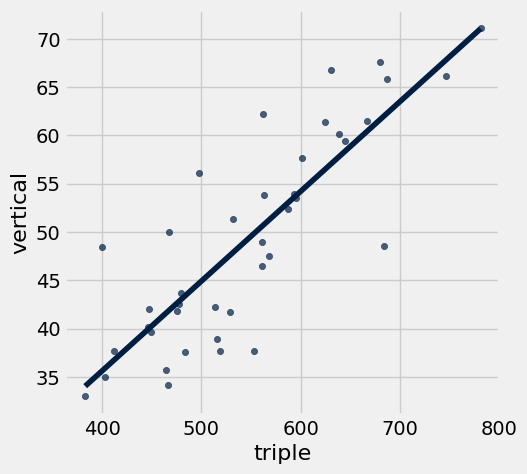

In [7]:
jumps.scatter("triple", "vertical", fit_line=True)

**Question 1.4. (2 pts)** Does the correlation coefficient $r$ look closest to 0, .5, or -.5? Explain.

The correlation coefficient looks closest to 0.5 because there is a clear linear pattern, so it cannot be 0, and the correlation appears to be positive based on the general slope of the data snd regression line, so it cannot be -0.5 either. Therefore, 0.5 seems the best option of the three for the correlation coefficient.

**Question 1.5. (6 pts)** Create a function called `parameter_estimates` that takes in the argument `tbl`, a two-column table where the first column is the x-axis and the second column is the y-axis. It should return an array with three elements: the **(1) correlation coefficient** of the two columns and the **(2) slope** and **(3) intercept** of the regression line that predicts the second column from the first, in original units. 

*Hint:* This is a rare occasion where it’s better to implement the function using column indices instead of column names, in order to be able to call this function on any table. If you need a reminder about how to use column indices to pull out individual columns, please refer to [this](https://www.inferentialthinking.com/chapters/06/Tables.html#accessing-the-data-in-a-column) section of the textbook.


In [8]:
def parameter_estimates(tbl):
    return make_array(correlation(tbl.column(0),tbl.column(1)),
                      (correlation(tbl.column(0),tbl.column(1))*(np.std(
                          tbl.column(1))/np.std(tbl.column(0)))),
                     (np.average(tbl.column(1)) - (correlation(tbl.column(
                         0),tbl.column(1))*(np.std(tbl.column(1))/np.std(
                         tbl.column(0))))*np.average(tbl.column(0))))


parameters = parameter_estimates(jumps) 
print('r:', parameters.item(0), '; slope:', parameters.item(1), '; intercept:', parameters.item(2))

r: 0.8343076972837598 ; slope: 0.09295728160512184 ; intercept: -1.566520972963474


In [9]:
grader.check("q1_5")

q1_5 results: All test cases passed!

**Question 1.6. (2 pts)** Now suppose you want to go the other way and predict a triple jump distance given a vertical jump distance. What would the regression parameters of this linear model be? How do they compare to the regression parameters from the model where you were predicting vertical jump distance given a triple jump distance (in Question 1.5)? 

Set `regression_changes` to an array of 3 elements, with each element corresponding to whether or not the corresponding item returned by `parameter_estimates` changes when switching vertical and triple as $x$ and $y$. For example, if r changes, the slope changes, but the intercept wouldn't change, the array would be `make_array(True, True, False)`.

In [ ]:
regression_changes = make_array(False, True, True)
regression_changes

In [11]:
grader.check("q1_6")

q1_6 results: All test cases passed!

**Question 1.7. (2 pts)** Let's use `parameters` (from Question 1.5) to predict what certain athletes' vertical jump heights would be given their triple jump distances.

The world record for the triple jump distance is 18.29 *meters* by Johnathan Edwards. What is the prediction for Edwards' vertical jump using this line?

*Hint:* Make sure to convert from meters to centimeters!

In [12]:
triple_record_vert_est = parameters.item(1)*(18.29*100) + parameters.item(2)
print("Predicted vertical jump distance: {:f} centimeters".format(triple_record_vert_est))

Predicted vertical jump distance: 168.452347 centimeters


In [13]:
grader.check("q1_7")

q1_7 results: All test cases passed!

**Question 1.8.(2 pts)** Do you think it makes sense to use this line to predict Edwards' vertical jump? 

*Hint:* Compare Edwards' triple jump distance to the triple jump distances in `jumps`. Is it relatively similar to the rest of the data? 

It does not make sense to use this line to predict Edward's vertical jump because he would be an outlier in the data set. Edward's triple jump distance is significantly greater than that of the athletes contained in the data set.

<!-- END QUESTION -->



## 2. Cryptocurrencies

Imagine you're an investor in December 2017. Cryptocurrencies, online currencies backed by secure software, are becoming extremely valuable, and you want in on the action!

The two most valuable cryptocurrencies are Bitcoin (BTC) and Ethereum (ETH). Each one has a dollar price attached to it at any given moment in time. For example, on December 1st, 2017, one BTC costs $\$10,859.56$ and one ETH costs $\$424.64.$

For fun, you can here are the current prices of [Bitcoin](https://www.coinbase.com/price/bitcoin) and [Ethereum](https://www.coinbase.com/price/ethereum)!

**You want to predict the price of ETH at some point in time based on the price of BTC.** Below, we load two [tables](https://www.kaggle.com/jessevent/all-crypto-currencies/data) called `btc` and `eth`. Each has 5 columns:
* `date`, the date
* `open`, the value of the currency at the beginning of the day
* `close`, the value of the currency at the end of the day
* `market`, the market cap or total dollar value invested in the currency
* `day`, the number of days since the start of our data

In [14]:
btc = Table.read_table('btc.csv')
btc

date,open,close,market,day
2015-09-29,239.02,236.69,3505090000,1
2015-09-30,236.64,236.06,3471280000,2
2015-10-01,236,237.55,3462800000,3
2015-10-02,237.26,237.29,3482190000,4
2015-10-03,237.2,238.73,3482100000,5
2015-10-04,238.53,238.26,3502460000,6
2015-10-05,238.15,240.38,3497740000,7
2015-10-06,240.36,246.06,3531230000,8
2015-10-07,246.17,242.97,3617400000,9
2015-10-08,243.07,242.3,3572730000,10


In [15]:
eth = Table.read_table('eth.csv')
eth

date,open,close,market,day
2015-09-29,0.579414,0.661146,42607700,1
2015-09-30,0.661192,0.738644,48636600,2
2015-10-01,0.734307,0.690215,54032300,3
2015-10-02,0.683732,0.678574,50328700,4
2015-10-03,0.678783,0.687171,49981900,5
2015-10-04,0.686343,0.668379,50556000,6
2015-10-05,0.666784,0.628643,49131600,7
2015-10-06,0.622218,0.650645,45863300,8
2015-10-07,0.650515,0.609388,47964700,9
2015-10-08,0.609501,0.621716,44955900,10


**Question 2.1. (3 pts)** In the cell below, create a line plot that visualizes the BTC and ETH open prices as a function of time. Both BTC and ETH open prices should be plotted on the same graph. 

*Hint:* Graph 1 shows the expected output.

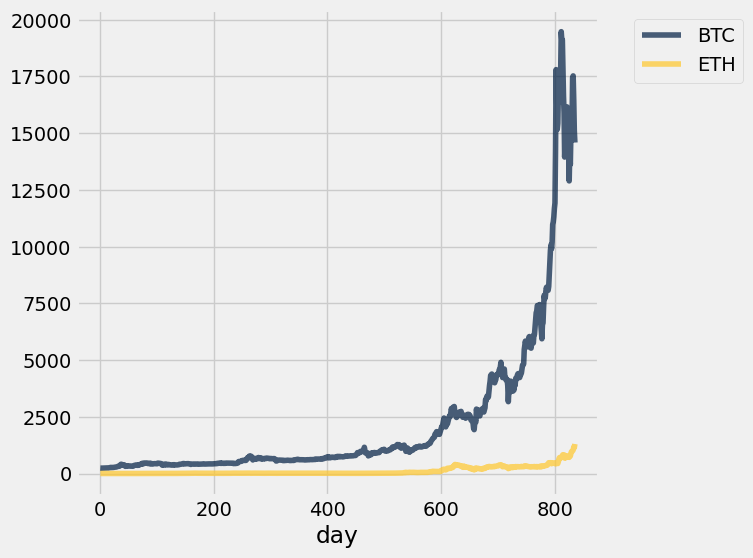

In [16]:
# Create a line plot of btc and eth open prices as a function of time
combo = btc.join("day", eth).relabel("open", "BTC").relabel("open_2", "ETH")
combo.plot("day", ["BTC", "ETH"])

Graph 1

<img src="Q2.1_graph.PNG" width="600" height="300"> 

**Question 2.2. (2 pts)** Now, calculate the correlation coefficient between the opening prices of BTC and ETH using the `correlation` function you defined earlier.

In [17]:
r = correlation(btc.column("open"), eth.column("open"))
r

0.92503257641482783

In [18]:
grader.check("q2_2")

q2_2 results: All test cases passed!

**Question 2.3. (4 pts)** Write a function `eth_predictor` which takes an opening BTC price and predicts the opening price of ETH. Again, it will be helpful to use the function `parameter_estimates` that you defined earlier in this homework.

In [19]:
def eth_predictor(btc_price):
    parameters = parameter_estimates(combo.select("BTC", "ETH"))
    slope = parameters.item(1)
    intercept = parameters.item(0)
    return slope*btc_price + intercept

In [20]:
grader.check("q2_3")

q2_3 results: All test cases passed!

**Question 2.4. (4 pts)** Now, using the `eth_predictor`, you defined in the previous question, make a scatter plot with BTC prices along the x-axis and both real and predicted ETH prices along the y-axis. The color of the dots for the real ETH prices should be different from the color for the predicted ETH prices.

*Hint 1:* Graph 2 shows the expected output.  An example of how such a scatter plot is generated can be found [here](https://inferentialthinking.com/chapters/15/2/Regression_Line.html).

*Hint 2:* Think about the table that must be produced and used to generate this scatter plot. What data should the columns represent? Based on the data that you need, how many columns should be present in this table? Also, what should each row represent? Constructing the table will be the main part of this question; once you have this table, generating the scatter plot should be straightforward as usual.

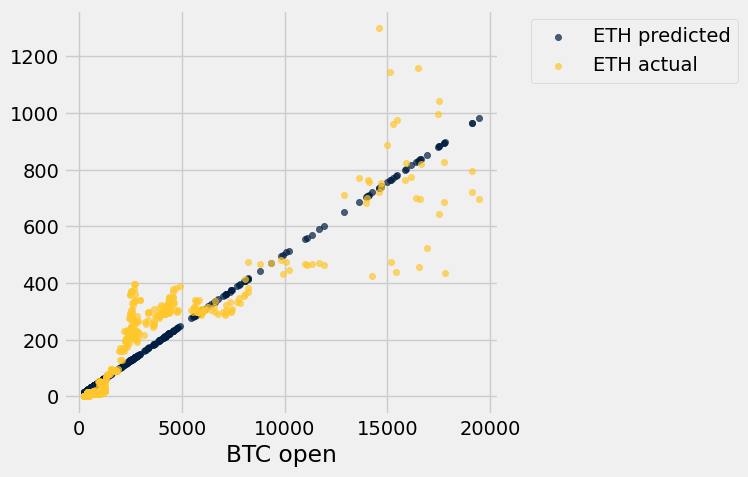

In [21]:
btc_open = btc.column("open")
eth_pred = btc.apply(eth_predictor, "open")
eth_pred_actual = eth.column("open")
Table().with_columns("BTC open", btc_open,
                    "ETH actual", eth_pred_actual,
                    "ETH predicted", eth_pred).scatter(
    "BTC open", ["ETH predicted", "ETH actual"])

Graph 2

<img src="Q2.4_graph.PNG" width="600" height="300"> 

**Question 2.5. (2 pts)** Considering the shape of the scatter plot of the true data, is the model we used reasonable? If so, what features or characteristics make this model reasonable? If not, what features or characteristics make it unreasonable? 

Given the dispersal of the true data, I'd say the model is reasonable because half the data points appear to lie below the "ETH predicted" line while the other half appear to be above it. This especially appears reasonable for the chunk of data below $10000 on the x-axis, as there is a more obvious shape here, which shows the predicted line seemingly right in-between this data.

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [22]:
grader.check_all()

q1_1 results: All test cases passed!

q1_2 results: All test cases passed!

q1_5 results: All test cases passed!

q1_6 results: All test cases passed!

q1_7 results: All test cases passed!

q2_2 results: All test cases passed!

q2_3 results: All test cases passed!


**Congratulations, you've completed Homework 11 (Last)!**

Please save your notebook, download a pdf version of the notebook, and submit it to Gradescope.

As this is your last homework, you may want to save/download **all your work** from this course on your own computer.  To do so, go to ood.discovery.neu.edu *Dashboard (or Home)*.
Instead of *Courses* or *My Interactive Sessions*, select *Files > Home Directory*. The contents of your home directory are displayed. To download a file/folder to your hard drive, navigate to the file/folder you want to download, select the file/folder, and click Download. If prompted by your browser, click OK to save your file to your hard drive.